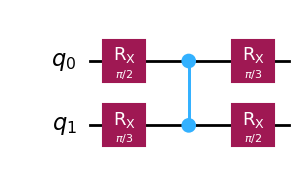

In [1]:
from qiskit.circuit.library import TwoLocal
from math import pi
 
reference_circuit = TwoLocal(2, "rx", "cz", entanglement="linear", reps=1)
theta_list = [pi / 2, pi / 3, pi / 3, pi / 2]
 
reference_circuit = reference_circuit.assign_parameters(theta_list)
 
reference_circuit.decompose().draw("mpl")

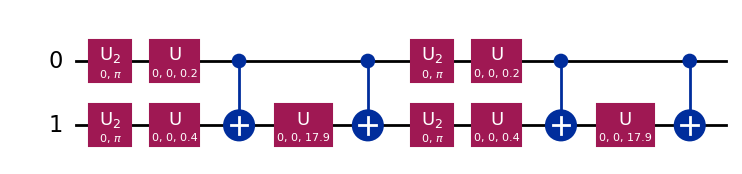

In [2]:
from qiskit.circuit.library import zz_feature_map
 
data = [0.1, 0.2]
 
zz_feature_map_reference = zz_feature_map(feature_dimension=2, reps=2)
zz_feature_map_reference = zz_feature_map_reference.assign_parameters(data)
zz_feature_map_reference.decompose().draw("mpl")

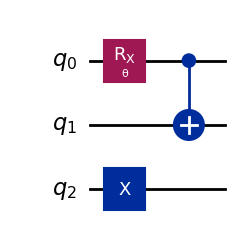

In [3]:
from qiskit.circuit import QuantumCircuit, Parameter
 
theta = Parameter("θ")
 
qc = QuantumCircuit(3)
qc.rx(theta, 0)
qc.cx(0, 1)
qc.x(2)
 
qc.draw("mpl")

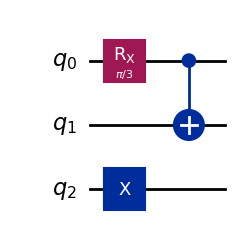

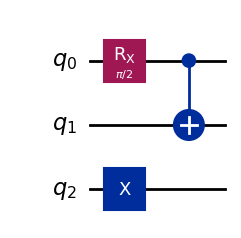

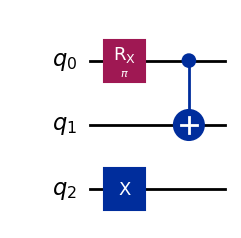

In [4]:
from math import pi
 
angle_list = [pi / 3, pi / 2 , pi]
circuits = [qc.assign_parameters({theta: angle}) for angle in angle_list]
 
for circuit in circuits:
    display(circuit.draw("mpl"))

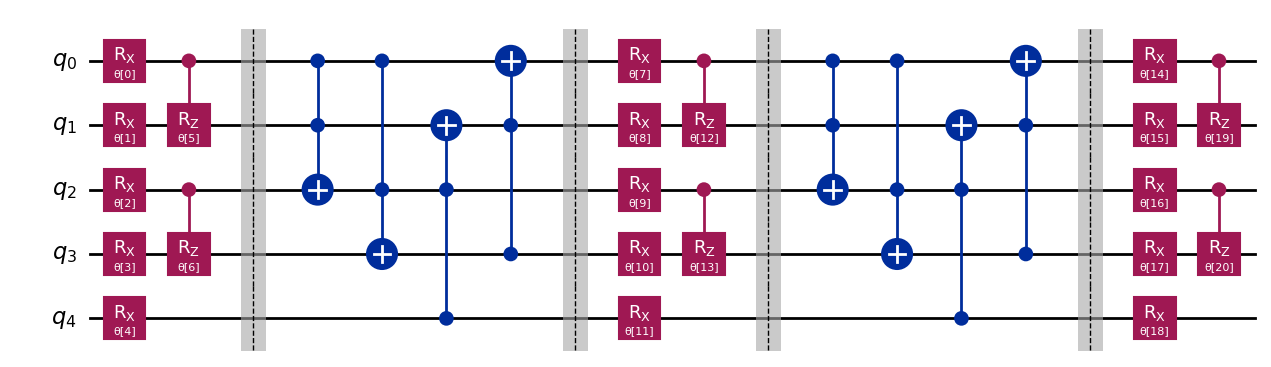

In [10]:
from qiskit.circuit.library import NLocal, CCXGate, CRZGate,RXGate
from qiskit.circuit import Parameter

theta = Parameter("θ")
anstaz = NLocal( 
                 num_qubits=5,
                 rotation_blocks=[RXGate(theta),CRZGate(theta)],
                 entanglement_blocks=CCXGate(),
                 entanglement=[[0,1,2],[0,2,3],[4,2,1],[3,1,0]],
                 reps=2,
                 insert_barriers=True)

anstaz.decompose().draw("mpl")

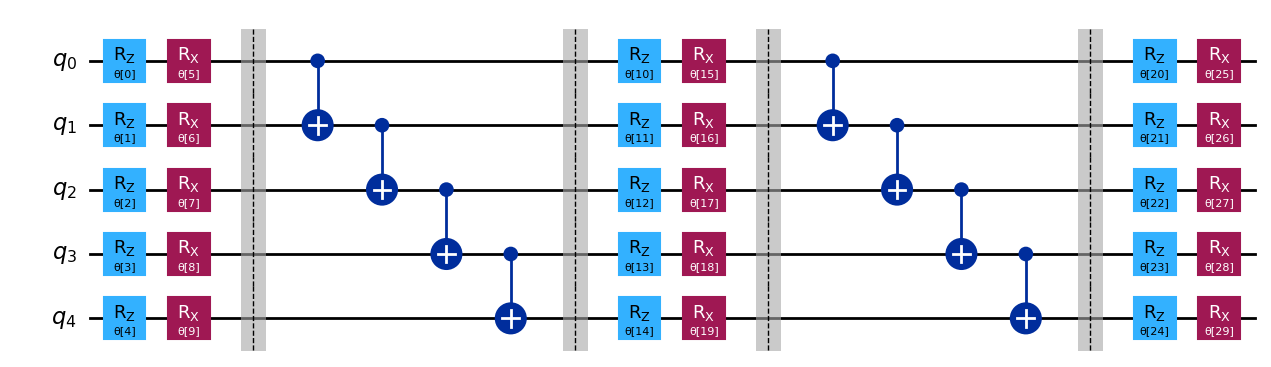

In [11]:
from qiskit.circuit.library import TwoLocal
from qiskit.circuit import Parameter

anstaz = TwoLocal(
    num_qubits=5,
    rotation_blocks=["rz", "rx"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=2,
    insert_barriers=True,
)
anstaz.decompose().draw("mpl")

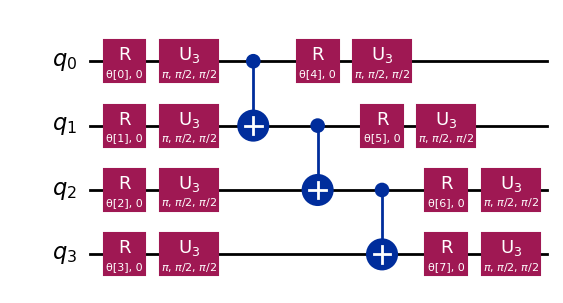

In [12]:
from qiskit.circuit.library import efficient_su2

anstaz = efficient_su2(4, su2_gates=["rx", "y"], entanglement="linear", reps=1)

anstaz.decompose().draw("mpl")

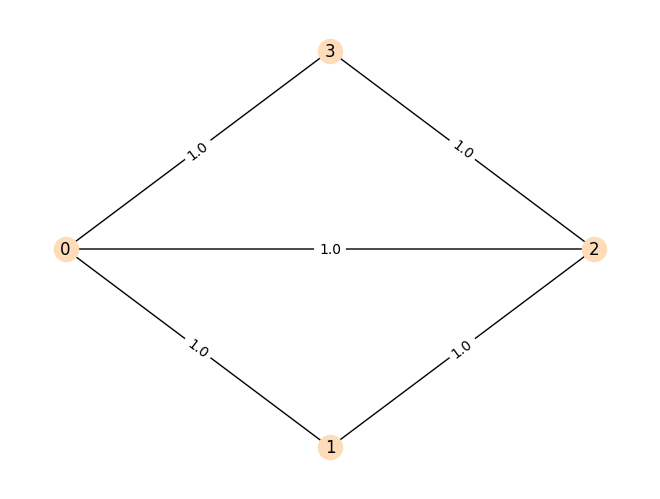

In [39]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw

n= 4
G=rx.PyGraph()
G.add_nodes_from(range(n))
edges = [(0,1,1.0), (0,2,1.0), (0,3,1.0),(1,2,1.0), (2,3,1.0)]
G.add_edges_from(edges)
mpl_draw(G, pos=rx.shell_layout(G),with_labels=True,edge_labels=str,node_color="#FEDCBA")

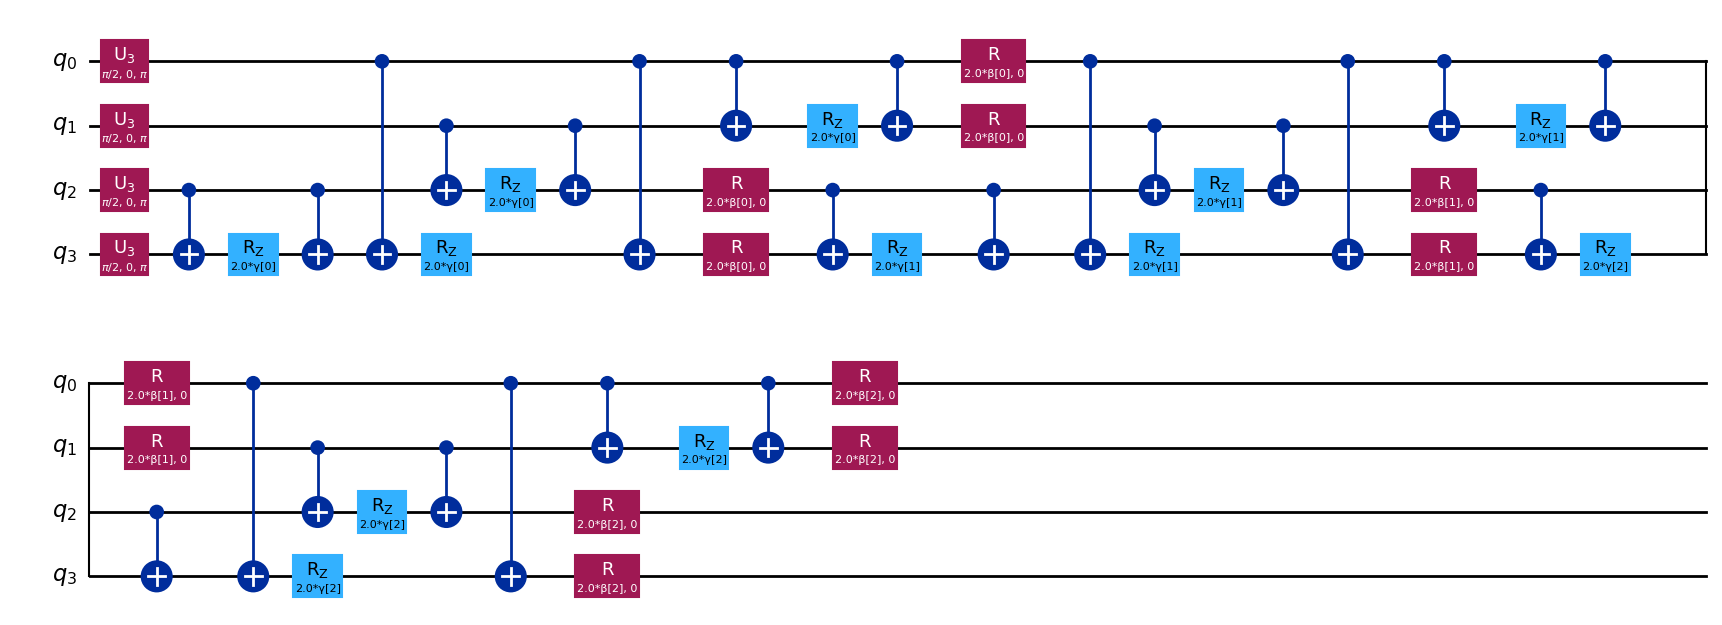

In [36]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp.from_list([("ZZII", 1), ("IZZI", 1), ("ZIIZ", 1), ("IIZZ", 1)])

anstaz = QAOAAnsatz(hamiltonian, reps=3)
anstaz.decompose(reps=3).draw("mpl")


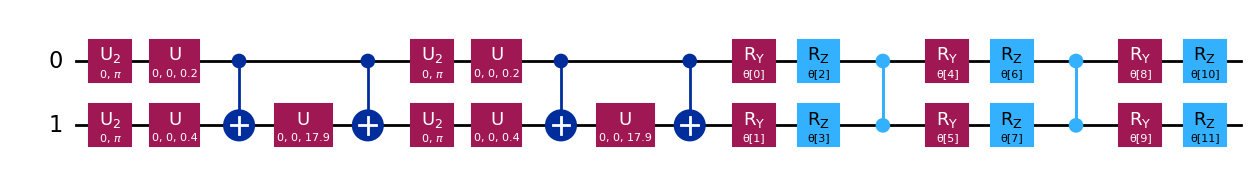

In [37]:
from qiskit.circuit.library import zz_feature_map, TwoLocal
 
data = [0.1, 0.2]
 
zz_feature_map_reference = zz_feature_map(feature_dimension=2, reps=2)
zz_feature_map_reference = zz_feature_map_reference.assign_parameters(data)
 
variation_form = TwoLocal(2, ["ry", "rz"], "cz", reps=2)
vqc_ansatz = zz_feature_map_reference.compose(variation_form)
vqc_ansatz.decompose().draw("mpl")

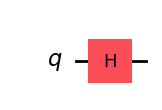

In [50]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

original_circuit = QuantumCircuit(1)
original_circuit.h(0)

H = SparsePauliOp(["X","Z"],[2,-1])

aux_circuits = []
for pauli in H.paulis:
    aux_circuit = original_circuit.copy()
    aux_circuit.barrier()
    if str(pauli)=="X":
        aux_circuit.h(0)
    elif str(pauli) == "Y":
        aux_circuit.sdg(0)
        aux_circuit.h(0)
    else:
        aux_circuit.id(0)
    aux_circuit.measure_all()
    aux_circuits.append(aux_circuit)

original_circuit.draw("mpl")

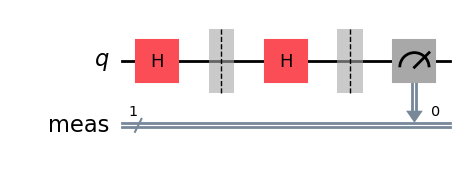

In [43]:
aux_circuits[0].draw("mpl")

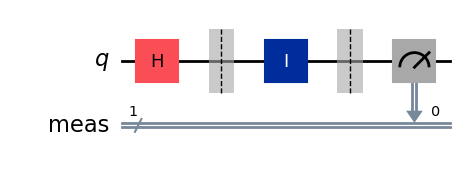

In [44]:
aux_circuits[1].draw("mpl")

In [54]:
from qiskit.primitives import StatevectorSampler,StatevectorEstimator
from qiskit.result import QuasiDistribution
from qiskit.circuit.library import IGate,ZGate,XGate
import numpy as np

# sampler
shots = 10000
sampler = StatevectorSampler()
job= sampler.run(aux_circuits,shots=shots)
data_pub = job.result()[1].data
bitstrings= data_pub.meas.get_bitstrings()
counts=data_pub.meas.get_counts()

quasi_dist = QuasiDistribution({outcome: freq/shots for outcome,freq in counts.items()})

expvals=[]
for pauli in H.paulis:
    val=0
    if str(pauli)== "I":
        Lambda = IGate().to_matrix().real
    elif str(pauli) == "X":
        Lambda = XGate().to_matrix().real
        val += Lambda [0][1] * quasi_dist.get(1)
        val += Lambda [1][0] * quasi_dist.get(0)
    elif str(pauli) == "Y":
        Lambda = XGate().to_matrix().real
        val += Lambda [0][1] * 1.0j * quasi_dist.get(1)
        val += Lambda [1][0] * -1.0j * quasi_dist.get(0)
    elif str(pauli) == "Z":
        Lambda = ZGate().to_matrix().real
        val += Lambda [0][0] * quasi_dist.get(0)
        val += Lambda [1][0] * quasi_dist.get(1)
    
    expvals.append(val)

print("Sampler Results")
for pauli, expval in zip(H.paulis, expvals):
    print(f"  >> Expected value of {str(pauli)}: {expval:.5f}")
 
total_expval = np.sum(H.coeffs * expvals).real
print(f"  >> Total expected value: {total_expval:.5f}")

# Estimator
observables = [
    *H.paulis,
    H,
]

estimator = StatevectorEstimator()
job=estimator.run([(original_circuit,observables)])
estimator_expvals = job.result()[0].data.evs

print("Estimator results:")
for obs, expval in zip(observables, estimator_expvals):
    if obs is not H:
        print(f"  >> Expected value of {str(obs)}: {expval:.5f}")
    else:
        print(f"  >> Total expected value: {expval:.5f}")


Sampler Results
  >> Expected value of X: 1.00000
  >> Expected value of Z: 0.50050
  >> Total expected value: 1.49950
Estimator results:
  >> Expected value of X: 1.00000
  >> Expected value of Z: 0.00000
  >> Total expected value: 2.00000
